In [1316]:
from qiskit import QuantumCircuit, transpile, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import numpy as np
from qiskit.circuit.library import QFT
from qiskit.quantum_info import Statevector
import base64
import pandas as pd
from fractions import Fraction

# 1) Quantum Fourier Transform

 1. When we apply QFT to $\ket{0010}$, we switch from computational basis to frequency basis and hence get an equal superposition of all the frequencie, with different phases. What happens in case of $f(x) = e^{i2x}$, is that when we discretize the function, it is already in a state of superposition and so extract the index from the amplitudes, we apply IQFT. When we encode a function into a quantum state, we are already in a Fourier superposition so we reverse the process.

    $\ket{Function Samples} \xrightarrow{IQFT} \ket{Frequency Index} $

2. Fourier Transform of $sin(2x)$ and $sin(8x)$

In [1317]:
n_qubits = 4
num_points = 2**n_qubits
x = np.linspace(0, 2*np.pi, num_points, endpoint=False)

def func(a):
    func_values = np.sin(a*x)
    return func_values / np.linalg.norm(func_values)

Let's first calculate FT of $sin(2x)$ :

Measurement counts: {'0010': 4874, '1110': 4726}


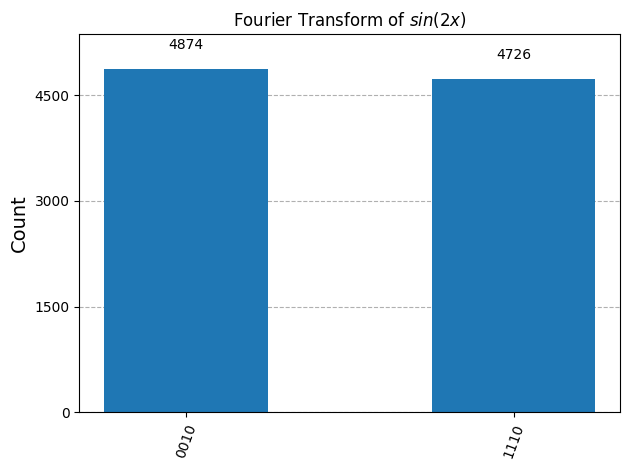

In [1318]:
qc_exp_1 = QuantumCircuit(n_qubits)
qft_circ_inv_1 = QFT(4, inverse=True)
qc_exp_1.initialize(func(2), range(n_qubits))
qc_exp_1.compose(qft_circ_inv_1, inplace=True)
qc_exp_1.measure_all()
simulator = AerSimulator()
qc_exp_comp_1 = transpile(qc_exp_1, simulator)
result_1 = simulator.run(qc_exp_comp_1, shots=9600).result()

counts_1 = result_1.get_counts()
print("Measurement counts:", counts_1)
plot_histogram(counts_1, title="Fourier Transform of $sin(2x)$")

3. We can write $sin(2x) =  \frac{1}{2i}(e^{i2x}-e^{-i2x})$. This means that $sin(2x)$ contains both frequency components, 2 and -2, with equal amplitude (though different phase). So when we apply inverse QFT, frequency 2 shows up as $\ket{2}$ and frequency -2 shows up as $\ket{2^4 - 2} = \ket{14}$.

If we were discretizing our function in $2^5$ dimensions instead, we would get an equal superposition of states $\ket{2}$ and $\ket{30}$.
I plotted a histogram for 5 qubits and the results are: 

Measurement counts: {'00010': 4787, '11110': 4813}


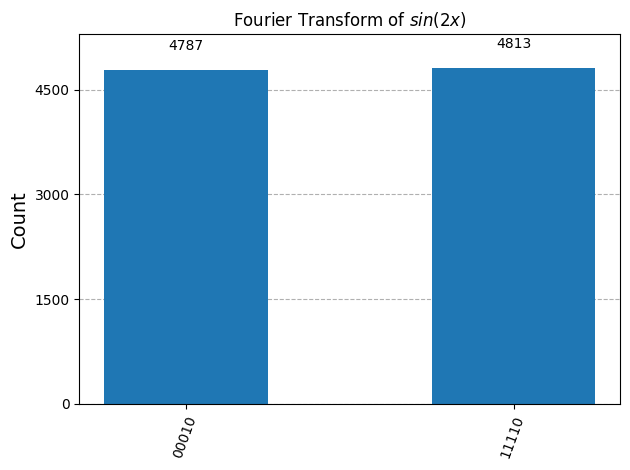

In [1319]:
x_1 = np.linspace(0, 2*np.pi, 32, endpoint=False)
func_values = np.sin(2*x_1)
normalized_values = func_values / np.linalg.norm(func_values)
qc_exp = QuantumCircuit(5)
qft_circ_inv = QFT(5, inverse=True)
qc_exp.initialize(normalized_values, range(5))
qc_exp.compose(qft_circ_inv, inplace=True)
qc_exp.measure_all()
simulator = AerSimulator()
qc_exp_comp = transpile(qc_exp, simulator)
result_4 = simulator.run(qc_exp_comp, shots=9600).result()

counts_4 = result_4.get_counts()
print("Measurement counts:", counts_4)
plot_histogram(counts_4, title="Fourier Transform of $sin(2x)$")

As we can see, we get almost equal no. of $\ket{00010} = \ket{2}$ and $\ket{11110} = \ket{30}$!

Now, for $sin(8x)$ :

Measurement counts: {'0101': 591, '1101': 849, '0100': 1210, '1000': 2961, '0011': 885, '1100': 1167, '1011': 642, '1001': 351, '1110': 133, '0110': 20, '0000': 200, '0111': 341, '0010': 134, '1010': 23, '0001': 44, '1111': 49}


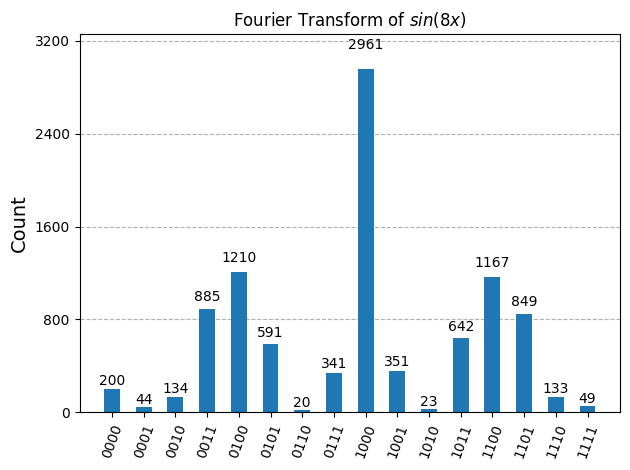

In [1320]:
qc_exp_2 = QuantumCircuit(n_qubits)
qft_circ_inv_2 = QFT(4, inverse=True)
qc_exp_2.initialize(func(8), range(n_qubits))
qc_exp_2.compose(qft_circ_inv_2, inplace=True)
qc_exp_2.measure_all()
simulator = AerSimulator()
qc_exp_comp_2 = transpile(qc_exp_2, simulator)
result_2 = simulator.run(qc_exp_comp_2, shots=9600).result()

counts_2 = result_2.get_counts()
print("Measurement counts:", counts_2)
plot_histogram(counts_2, title="Fourier Transform of $sin(8x)$")

4. We are getting these small peaks at other frequencies purely because of the fact that we are working with 4 qubits or 16 basis states. Before explaining it further, let's try discretizing the same function and plotting the results with 5 qubits or 32 dimensions :

Measurement counts: {'01000': 4809, '11000': 4791}


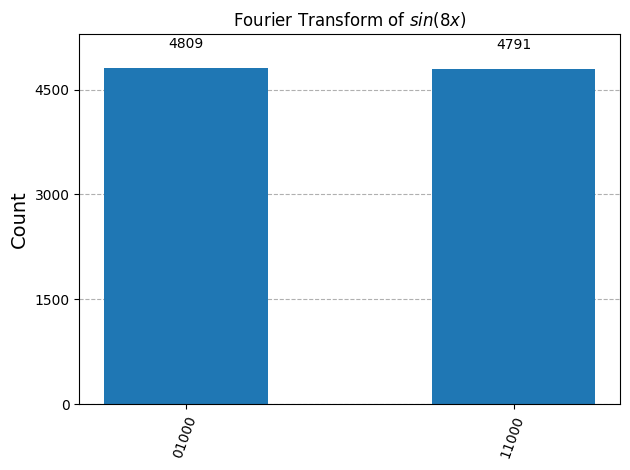

In [1321]:
x_2 = np.linspace(0, 2*np.pi, 32, endpoint=False)
func_values_1 = np.sin(8*x_2)
normalized_values_1 = func_values_1 / np.linalg.norm(func_values_1)
qc_exp_3 = QuantumCircuit(5)
qft_circ_inv_3 = QFT(5, inverse=True)
qc_exp_3.initialize(normalized_values_1, range(5))
qc_exp_3.compose(qft_circ_inv_3, inplace=True)
qc_exp_3.measure_all()
simulator = AerSimulator()
qc_exp_comp_3 = transpile(qc_exp_3, simulator)
result_3 = simulator.run(qc_exp_comp_3, shots=9600).result()

counts_3 = result_3.get_counts()
print("Measurement counts:", counts_3)
plot_histogram(counts_3, title="Fourier Transform of $sin(8x)$")

We are getting exactly the expected outcome, i.e., equal superposition of states $\ket{01000} = \ket{8}$ and $\ket{11000} = \ket{24}$!

5. A major problem with Amplitude Encoding is that, as the amount of training data increases, the training error may increase rather than decrease, leading to reduced decrease in prediction accuracy on new data. Preparing a generic state for arbitrary data $f(x_i)$ requires $\mathcal{O}(2^n)$ quantum gates and hence, is hard to prepare.
Few alternates are:
1) Hamiltonian Encoding
2) Qsample Encoding 
3) Basis Encoding

References: https://arxiv.org/pdf/2503.01545, https://hgmin1159.github.io/quantum/quantumml2/

# 2) Estimating Excited State Energy of a Quantum Material for Battery Design

1. The reason we divide by 4 is due to periodicity of $e^{i 2 \pi \phi}$. Say $\theta = 3.8$ is our excited state energy value, then $e^{2 \pi i \times 3.8 } = e^{2\pi i \times 0.8}$ $\implies$ Quantum Phase Estimation can only output $\phi \in [0,1)$. So, we scale our $\phi = 2\pi \theta /4$ and multiply our result by 4 to get $\theta$! 

2. Implementing Quantum Phase Estimation Circuit

First let's extract encrypted theta.

In [1322]:
import base64

with open("theta.txt", "r") as f:
    encoded_theta = f.read()

theta = float(base64.b64decode(encoded_theta).decode())

Now, we form our QPE circuit.

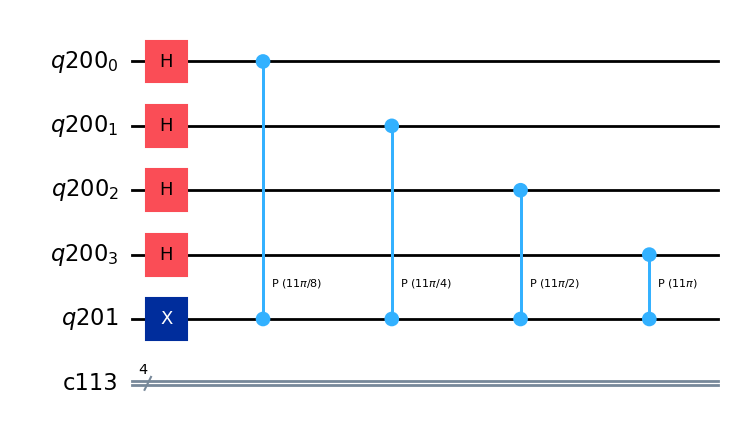

In [1323]:
t = 4 #number of qubits in our first register for precision

q_1 = QuantumRegister(t)
q_2 = QuantumRegister(1)
c_1 = ClassicalRegister(t)

qc_qpe = QuantumCircuit(q_1, q_2, c_1)
qc_qpe.h(q_1)
qc_qpe.x(q_2[0])  # As we want eigenvalue of 1 
for j in range(t):
    phi = theta / 4
    angle = 2 * np.pi * phi * (2**j)   # this is the only place θ/4 enters
    qc_qpe.cp(angle, j, t)

qc_qpe.draw('mpl', fold=-1)

We will now apply inverse QFT.


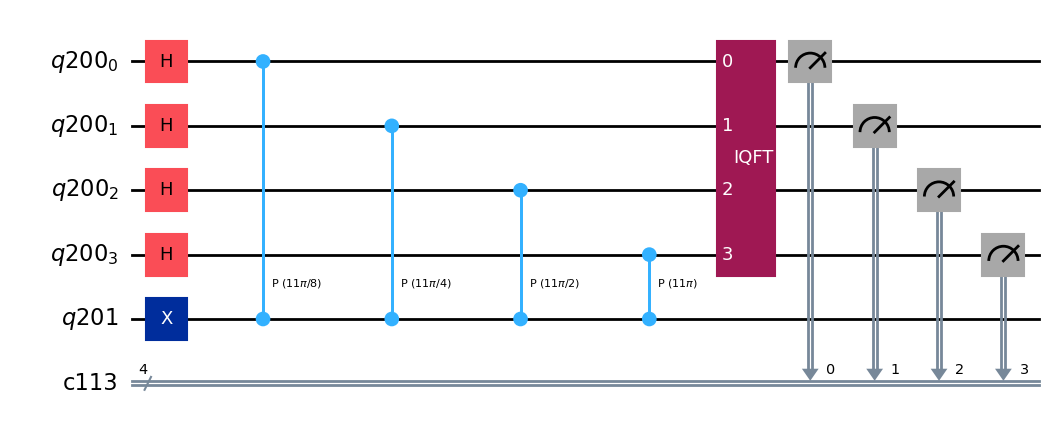

In [1324]:
qc_qpe.append(QFT(t, inverse=True), range(t))

qc_qpe.measure(q_1, c_1)

qc_qpe.draw('mpl', fold=-1)

3. Let's simulate the circuit and find value of the phase.

In [1325]:
simulator = AerSimulator()
qc_qpe_comp = transpile(qc_qpe, simulator)
result = simulator.run(qc_qpe_comp, shots=9600).result()
counts = result.get_counts()
print("Measurement counts:", counts)

Measurement counts: {'1011': 9600}


We shall take the result with highest counts and convert it to decimal to find the phase.

In [1326]:

bitstring = max(counts, key=counts.get)

phi = int(bitstring, 2) / 2**t

final_theta = phi * 4
print("φ:", phi)
print("θ:", final_theta)

φ: 0.6875
θ: 2.75


Let's check our answer :

In [1327]:
print(theta)

2.75


Nailed it!

# 3) Breaking Simplified RSA Protocol with Shor’s Algorithm

1. Finding factors of 15 using $a=7$.

In [1339]:
a = 7
N = 15
n_work = 4
n_control = 2 * n_work

qr = QuantumRegister(n_work, name='work')
qr2 = QuantumRegister(n_control, name='control')
cr = ClassicalRegister(n_control, name='measure')
qc_shor = QuantumCircuit(qr2, qr, cr)

qc_shor.x(n_control)

for qubit in range(n_control):
    qc_shor.h(qr2[qubit])

def c_amod15(a, power):
    if a not in [2, 4, 7, 8, 11, 13]:
        raise ValueError("'a' must be 2, 4, 7, 8, 11 or 13")
    U = QuantumCircuit(4)
    for _ in range(power):
        if a in [2, 13]:
            U.swap(2, 3)
            U.swap(1, 2)
            U.swap(0, 1)
        if a in [7, 8]:
            U.swap(0, 1)
            U.swap(1, 2)
            U.swap(2, 3)
        if a in [4, 11]:
            U.swap(1, 3)
            U.swap(0, 2)
        if a in [7, 11, 13]:
            for q in range(4):
                U.x(q)
    return U.to_gate().control()

for q in range(n_control):
    qc_shor.append(c_amod15(a, 2**q), [qr2[q]] + [qr[i] for i in range(4)])

qc_shor.append(QFT(n_control, inverse=True), qr2)
qc_shor.measure(qr2, cr)

simulator = AerSimulator()
compiled_qc_shor = transpile(qc_shor, simulator)
result = simulator.run(compiled_qc_shor, shots=1000).result()
counts = result.get_counts()
plot_histogram(counts)

measured_phases = [int(k, 2) / (2**n_control) for k in counts]
rows, candidate = [], []

for phase in measured_phases:
    frac = Fraction(phase).limit_denominator(N)
    candidate.append(frac.denominator)
    rows.append([phase, f"{frac.numerator}/{frac.denominator}", frac.denominator])

df = pd.DataFrame(rows, columns=["Phase", "Fraction", "Guess for r"])
print(df)

for r in candidate:
    print(f"For r = {r}")
    if r % 2 == 0:
        x = pow(a, r // 2, N)
        factors = [np.gcd(x - 1, N), np.gcd(x + 1, N)]
        print("Factors of 15:", [int(f) for f in factors if f not in [1, N]])
    else:
        print("Period 'r' is odd. Try another 'a'.")

   Phase Fraction  Guess for r
0   0.50      1/2            2
1   0.00      0/1            1
2   0.25      1/4            4
3   0.75      3/4            4
For r = 2
Factors of 15: [3]
For r = 1
Period 'r' is odd. Try another 'a'.
For r = 4
Factors of 15: [3, 5]
For r = 4
Factors of 15: [3, 5]


So we get $p=3, q=5$.

2. $\phi(N) = (3-1)\times(5-1) = 8$.

3. We want, $ 7d \equiv 1$ mod $8$

In [1340]:
pow(7, -1, 8)

7

We get $d=7$.

4. Let's decrypt the message. We know, 
    $ m = c^d \mod 15$

    Performing calculations: 
    $14^7 \mod 15 = 14$, 
    $9^7 \mod 15 = 9 $, 
    $12^7 \mod 15 = 3 $, 
    $ 5^7\mod 15 = 5$, 

5. [N,I,C,E]

Nice!